In [1]:
from src.experimenthandling import ExperimentAnalyzer
import logging
logging.basicConfig(level=logging.ERROR, format="%(asctime)s %(name)s %(levelname)s %(message)s")

def load_and_return(experiment: str) -> ExperimentAnalyzer:
    exp = ExperimentAnalyzer(experiment)
    # exp.load_models()
    exp.load_metrics()
    return exp

exp1a = load_and_return('experiment_1a')

2026-08-21 11:31:14,203 src.experimenthandling.containers INFO ExperimentConfig loaded from /scratch/de-schrijvers/projects/infectious_disease_gnn/data/experiment_outcomes/experiment_1a/_experiment_config.yaml
2026-08-21 11:31:14,204 src.experimenthandling.loader INFO Setting dataloadermanagers ...
2026-08-21 11:31:16,332 src.graphconstruction.graphobjects.graphobject INFO Graph graph6 loaded from file.
2026-08-21 11:31:16,652 src.graphconstruction.graphobjects.graphobject INFO Graph graph2 loaded from file.
2026-08-21 11:31:16,959 src.graphconstruction.graphobjects.graphobject INFO Graph graph3 loaded from file.
2026-08-21 11:31:17,264 src.graphconstruction.graphobjects.graphobject INFO Graph graph5 loaded from file.
2026-08-21 11:31:17,729 src.graphconstruction.graphobjects.graphobject INFO Graph graph1 loaded from file.
2026-08-21 11:31:18,038 src.graphconstruction.graphobjects.graphobject INFO Graph graph4 loaded from file.
2026-08-21 11:31:20,274 src.graphconstruction.graphobjects

In [2]:
graph1 = exp1a.dataloadermanagers[1].graphs['graph1'].dataloader_main.data_list[0].graph
graph2 = exp1a.dataloadermanagers[1].graphs['graph2'].dataloader_main.data_list[0].graph
graph3 = exp1a.dataloadermanagers[1].graphs['graph3'].dataloader_main.data_list[0].graph
graph6 = exp1a.dataloadermanagers[1].graphs['graph6'].dataloader_main.data_list[0].graph

global_shapedata =exp1a.dataloadermanagers[1].graphs['graph1'].dataorchestrator.data_context.global_shapedata
local_shapedata = exp1a.dataloadermanagers[1].graphs['graph1'].dataorchestrator.data_context.local_shapedata
tokenization_map =exp1a.dataloadermanagers[1].graphs['graph1'].dataorchestrator.data_context.tokenization_map

In [3]:
# Global shapedata map
import matplotlib.pyplot as plt 
import seaborn as sns
import geopandas as gpd
import numpy as np
from src.graphconstruction.graphobjects import GraphStructure

In [ ]:
def get_neighborhood(graph: GraphStructure, key: int):

    token          = tokenization_map[key]
    adj            = graph._get_adjacency_matrix().numpy()
    adj_token      = adj[:,token]
    neighborhood    = np.where(adj_token > 0)[0]
    return neighborhood


In [67]:
import numpy as np
import pandas as pd
from shapely.ops import unary_union

def get_neighborhood_distance(graph, key):
    nodes = get_neighborhood(graph, key)
    neighborhood_shape = local_shapedata[local_shapedata['node'].isin(nodes + tokenization_map[key])]

    n_nodes = len(neighborhood_shape)

    if n_nodes == 0:
        return {'key': key, 'n_nodes': 0, 'mean_dist': np.nan}

    pts = neighborhood_shape.geometry.representative_point()
    xs, ys = pts.x.values, pts.y.values
    cx, cy = xs.mean(), ys.mean()
    mean_dist = np.mean(np.sqrt((xs - cx) ** 2 + (ys - cy) ** 2))

    return {'key': key, 'n_nodes': n_nodes, 'mean_dist': mean_dist}

rows = []
for key in list(tokenization_map.keys()):
    rows.append(get_neighborhood_distance(graph6, key))

results = pd.DataFrame(rows)

# drop keys that had no matching shapes (NaNs), and single-node neighborhoods (trivial 0s)
results_clean = results[results['n_nodes'] > 1].dropna(subset=['mean_dist'])

most_condensed = results_clean.sort_values('mean_dist')
print(most_condensed)

       key  n_nodes  mean_dist
247  09263        2   0.209827
79   05315        2   0.394362
356  14612        2   0.424346
245  09261        2   0.445060
373  15087        2   0.474001
..     ...      ...        ...
105  05913        4   3.009207
72   05124        9   3.032174
55   03457        5   3.138043
177  07340        6   3.220285
178  08111        2   3.652794

[282 rows x 3 columns]


TypeError: 'Spines' object is not callable

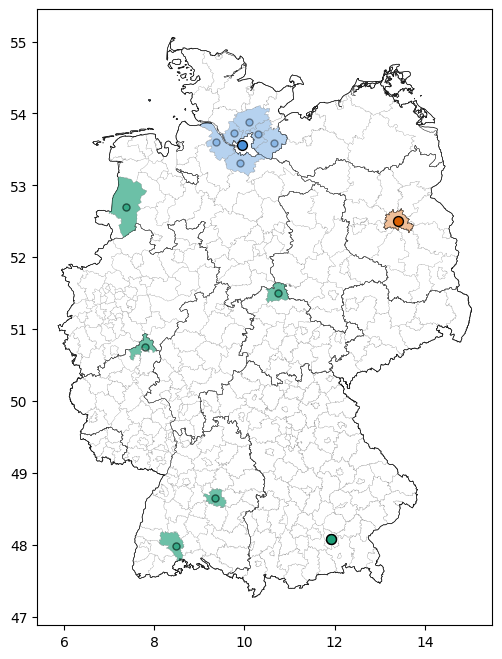